# B142 Data Integration
## E-Commerce Data Integration and Scalable Analytics Using Apache Spark
**Dataset:** Olist Brazilian E-Commerce Public Dataset (Kaggle) &nbsp;|&nbsp; **Tools:** Google Colab · PySpark · Spark SQL · Parquet · Matplotlib

**Pipeline:** OLIST → PYSPARK → INGESTION → QUALITY → CLEANING → SCHEMA → JOINS → TRANSFORMATIONS → ETL → PARQUET → SPARK SQL → CALCULATIONS → STATISTICS → VISUALIZATIONS → INSIGHTS

# 1. Introduction
The Olist dataset contains real orders from a Brazilian e-commerce marketplace. The information is **distributed across multiple CSV files**: customers, orders, order items, products, sellers, payments and reviews. On its own, no single file can answer business questions such as which product categories generate the most sales or how delivery time differs between states.

The objective of this project is to **integrate and process these files using Apache Spark** and produce useful analytical information. Spark is used because its DataFrame API and Spark SQL engine process data in parallel and the same code can scale to much larger datasets.

**Objectives**
1. Ingest the raw data using Apache Spark.
2. Clean and preprocess the data.
3. Align schemas.
4. Integrate related datasets.
5. Transform the integrated data.
6. Build an ETL pipeline.
7. Save processed data in Parquet.
8. Analyse the data using Spark SQL.
9. Perform calculations and basic statistics.
10. Visualize important results.
11. Produce actionable insights.

# 2. Spark Setup

In [1]:
# Install PySpark (Google Colab does not always include it)
import importlib.util, subprocess, sys
if importlib.util.find_spec("pyspark") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyspark==3.5.1"], check=True)

In [2]:
import os, time
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType, StringType
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

spark = (SparkSession.builder
         .appName("B142_Olist_Data_Integration")
         .master("local[*]")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.ui.showConsoleProgress", "false")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

print("Spark version:", spark.version)
print("Master:", spark.sparkContext.master)

timings = {}                       # real measured processing times
os.makedirs("charts", exist_ok=True)

26/09/16 20:56:45 WARN Utils: Your hostname, vm resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/09/16 20:56:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/16 20:56:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.1
Master: local[*]


# 3. Dataset Loading
The Olist CSV files are used as raw input. If they are not already uploaded to Colab (`/content` or `data/`), the cell below downloads the public Kaggle dataset with `kagglehub`.

| File | Used for |
|---|---|
| olist_customers_dataset.csv | customer location |
| olist_orders_dataset.csv | order status and dates |
| olist_order_items_dataset.csv | products sold, price, freight |
| olist_order_payments_dataset.csv | payment type and value |
| olist_order_reviews_dataset.csv | review score |
| olist_products_dataset.csv | product category |
| olist_sellers_dataset.csv | seller location |
| product_category_name_translation.csv | English category names |

The geolocation file is **not used** because none of the planned analyses need latitude/longitude.

In [3]:
FILES = {
    "customers":            "olist_customers_dataset.csv",
    "orders":               "olist_orders_dataset.csv",
    "order_items":          "olist_order_items_dataset.csv",
    "payments":             "olist_order_payments_dataset.csv",
    "reviews":              "olist_order_reviews_dataset.csv",
    "products":             "olist_products_dataset.csv",
    "sellers":              "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}
DATA_DIR = None
for candidate in ["data", "/content", "/content/data", "."]:
    if os.path.exists(os.path.join(candidate, FILES["orders"])):
        DATA_DIR = candidate; break
if DATA_DIR is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
    import kagglehub
    DATA_DIR = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Raw data folder:", DATA_DIR)

Raw data folder: data


**EXTRACT.** Every file is read with `spark.read.csv`. `inferSchema` is switched off so that all columns arrive as strings and every type conversion is done explicitly (Sections 6–7). The reviews file contains comments with line breaks inside quotes, so it is read with `multiLine=True` and `escape='"'`.

In [4]:
def read_csv(file_name, multiline=False):
    return (spark.read
            .option("header", True)
            .option("inferSchema", False)
            .option("multiLine", multiline)
            .option("escape", '"')
            .csv(os.path.join(DATA_DIR, file_name)))

t0 = time.time()
raw = {name: read_csv(f, multiline=(name == "reviews")) for name, f in FILES.items()}
for df in raw.values():
    df.cache()
load_summary = [(name, df.count(), len(df.columns)) for name, df in raw.items()]
timings["Data ingestion"] = time.time() - t0

spark.createDataFrame(load_summary, ["dataset", "rows", "columns"]).show(truncate=False)
print("Total raw rows:", sum(r for _, r, _ in load_summary))

+--------------------+------+-------+
|dataset             |rows  |columns|
+--------------------+------+-------+
|customers           |99441 |5      |
|orders              |99441 |8      |
|order_items         |112650|7      |
|payments            |103886|5      |
|reviews             |99224 |7      |
|products            |32951 |9      |
|sellers             |3095  |4      |
|category_translation|71    |2      |
+--------------------+------+-------+

Total raw rows: 550759


In [5]:
for name, df in raw.items():
    print("=" * 25, name, "| rows:", df.count(), "=" * 25)
    df.show(5, truncate=30)
    df.printSchema()

========================= customers | rows: 99441 =========================


+------------------------------+------------------------------+------------------------+---------------------+--------------+
|                   customer_id|            customer_unique_id|customer_zip_code_prefix|        customer_city|customer_state|
+------------------------------+------------------------------+------------------------+---------------------+--------------+
|06b8999e2fba1a1fbc88172c00b...|861eff4711a542e4b93843c6dd7...|                   14409|               franca|            SP|
|18955e83d337fd6b2def6b18a42...|290c77bc529b7ac935b93aa66c3...|                   09790|sao bernardo do campo|            SP|
|4e7b3e00288586ebd08712fdd03...|060e732b5b29e8181a18229c7b0...|                   01151|            sao paulo|            SP|
|b2b6027bc5c5109e529d4dc6358...|259dac757896d24d7702b9acbbf...|                   08775|      mogi das cruzes|            SP|
|4f2d8ab171c80ec8364f7c12e35...|345ecd01c38d18a9036ed96c73b...|                   13056|             campinas|        

========================= orders | rows: 99441 =========================


+------------------------------+------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|                      order_id|                   customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+------------------------------+------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b7cc49136f2...|9ef432eb6251297304e76186b10...|   delivered|     2017-10-02 10:56:33|2017-10-02 11:07:15|         2017-10-04 19:55:00|          2017-10-10 21:25:13|          2017-10-18 00:00:00|
|53cdb2fc8bc7dce0b6741e21502...|b0830fb4747a6c6d20dea0b8c80...|   delivered|     2018-07-24 20:41:37|2018-07-26 03:24:27|         2018-07-26 14:31:00|      

========================= order_items | rows: 112650 =========================


...

+------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|                    product_id|product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|1e9e8ef04dbcff4541ed26657ea...|           perfumaria|                 40|                       287|                 1|             225|               16|               10|              14|
|3aa071139cb16b67ca9e5dea641...|                artes|                 44|                       276|                 1|            1000|               30|               18|              20|
|96bd76ec8810374ed1b65e29197...|        espor

========================= sellers | rows: 3095 =========================


+------------------------------+----------------------+-----------------+------------+
|                     seller_id|seller_zip_code_prefix|      seller_city|seller_state|
+------------------------------+----------------------+-----------------+------------+
|3442f8959a84dea7ee197c632cb...|                 13023|         campinas|          SP|
|d1b65fc7debc3361ea86b5f14c6...|                 13844|       mogi guacu|          SP|
|ce3ad9de960102d0677a81f5d0b...|                 20031|   rio de janeiro|          RJ|
|c0f3eea2e14555b6faeea3dd58c...|                 04195|        sao paulo|          SP|
|51a04a8a6bdcb23deccc82b0b80...|                 12914|braganca paulista|          SP|
+------------------------------+----------------------+-----------------+------------+
only showing top 5 rows

root
 |-- seller_id: string (nullable = true)
 |-- seller_zip_code_prefix: string (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)



========================= category_translation | rows: 71 =========================


+----------------------+-----------------------------+
| product_category_name|product_category_name_english|
+----------------------+-----------------------------+
|          beleza_saude|                health_beauty|
|informatica_acessorios|        computers_accessories|
|            automotivo|                         auto|
|       cama_mesa_banho|               bed_bath_table|
|      moveis_decoracao|              furniture_decor|
+----------------------+-----------------------------+
only showing top 5 rows

root
 |-- product_category_name: string (nullable = true)
 |-- product_category_name_english: string (nullable = true)



# 4. Data Understanding
**Keys**

| Key | Unique in | Used to join |
|---|---|---|
| `customer_id` | customers | orders |
| `order_id` | orders | order_items, payments, reviews |
| `product_id` | products | order_items |
| `seller_id` | sellers | order_items |

**Integration structure**
```
customers
   ↓ customer_id
orders ──order_id──> payments
   │   ──order_id──> reviews
   ↓ order_id
order_items ──seller_id──> sellers
   ↓ product_id
products
```

In [6]:
# How many rows per order? (one-to-many relationships)
for name in ["order_items", "payments", "reviews"]:
    per_order = raw[name].groupBy("order_id").count()
    s = per_order.agg(F.max("count").alias("max"),
                      F.sum(F.when(F.col("count") > 1, 1).otherwise(0)).alias("orders_with_more_than_1")).first()
    print(f"{name:12s} rows per order -> max {s['max']:>3}, orders with more than one row: {s['orders_with_more_than_1']:,}")

print("customer_id values:", raw["customers"].select("customer_id").distinct().count(),
      "| customer_unique_id values:", raw["customers"].select("customer_unique_id").distinct().count())

order_items  rows per order -> max  21, orders with more than one row: 9,803


payments     rows per order -> max  29, orders with more than one row: 2,961


reviews      rows per order -> max   3, orders with more than one row: 547


customer_id values: 99441 | customer_unique_id values: 96096


**Observation:** orders → order_items, payments and reviews are **one-to-many**. Joining them directly would multiply rows, so these relationships are handled carefully in Section 8. Olist also gives a new `customer_id` to every order, so real customers are counted with `customer_unique_id`.

### Schema inspection (before cleaning)

In [7]:
for name in ["orders", "order_items", "payments", "reviews", "products"]:
    print(f"{name:12s}", raw[name].dtypes)

orders       [('order_id', 'string'), ('customer_id', 'string'), ('order_status', 'string'), ('order_purchase_timestamp', 'string'), ('order_approved_at', 'string'), ('order_delivered_carrier_date', 'string'), ('order_delivered_customer_date', 'string'), ('order_estimated_delivery_date', 'string')]
order_items  [('order_id', 'string'), ('order_item_id', 'string'), ('product_id', 'string'), ('seller_id', 'string'), ('shipping_limit_date', 'string'), ('price', 'string'), ('freight_value', 'string')]
payments     [('order_id', 'string'), ('payment_sequential', 'string'), ('payment_type', 'string'), ('payment_installments', 'string'), ('payment_value', 'string')]
reviews      [('review_id', 'string'), ('order_id', 'string'), ('review_score', 'string'), ('review_comment_title', 'string'), ('review_comment_message', 'string'), ('review_creation_date', 'string'), ('review_answer_timestamp', 'string')]
products     [('product_id', 'string'), ('product_category_name', 'string'), ('product_name_

All columns are `string`: dates, prices, payment values and review scores must be converted before any calculation.

# 5. Data Quality Assessment
Performed **before** cleaning, so every cleaning action is based on evidence.

### 5.1 Missing values

In [8]:
t0 = time.time()
missing_rows = []
for name, df in raw.items():
    total = df.count()
    counts = df.agg(*[F.sum(F.when(F.col(c).isNull() | (F.trim(F.col(c)) == ""), 1).otherwise(0)).alias(c)
                      for c in df.columns]).first().asDict()
    missing_rows += [(name, c, n, round(100 * n / total, 2)) for c, n in counts.items() if n > 0]
spark.createDataFrame(missing_rows, ["dataset", "column", "missing", "missing_pct"]) \
     .orderBy(F.desc("missing")).show(truncate=False)

+--------+-----------------------------+-------+-----------+
|dataset |column                       |missing|missing_pct|
+--------+-----------------------------+-------+-----------+
|reviews |review_comment_title         |87658  |88.34      |
|reviews |review_comment_message       |58256  |58.71      |
|orders  |order_delivered_customer_date|2965   |2.98       |
|orders  |order_delivered_carrier_date |1783   |1.79       |
|products|product_category_name        |610    |1.85       |
|products|product_name_lenght          |610    |1.85       |
|products|product_description_lenght   |610    |1.85       |
|products|product_photos_qty           |610    |1.85       |
|orders  |order_approved_at            |160    |0.16       |
|products|product_weight_g             |2      |0.01       |
|products|product_length_cm            |2      |0.01       |
|products|product_height_cm            |2      |0.01       |
|products|product_width_cm             |2      |0.01       |
+--------+--------------

### 5.2 Duplicates

In [9]:
dup_checks = [("customers", ["customer_id"]), ("orders", ["order_id"]), ("products", ["product_id"]),
              ("sellers", ["seller_id"]), ("order_items", ["order_id", "order_item_id"]),
              ("payments", ["order_id", "payment_sequential"]), ("reviews", ["review_id"])]
dup_rows = []
for name, key in dup_checks:
    df = raw[name]; n = df.count()
    dup_rows.append((name, "+".join(key), n - df.distinct().count(), n - df.select(*key).distinct().count()))
spark.createDataFrame(dup_rows, ["dataset", "expected_unique_key", "duplicate_rows", "duplicate_keys"]).show(truncate=False)

+-----------+---------------------------+--------------+--------------+
|dataset    |expected_unique_key        |duplicate_rows|duplicate_keys|
+-----------+---------------------------+--------------+--------------+
|customers  |customer_id                |0             |0             |
|orders     |order_id                   |0             |0             |
|products   |product_id                 |0             |0             |
|sellers    |seller_id                  |0             |0             |
|order_items|order_id+order_item_id     |0             |0             |
|payments   |order_id+payment_sequential|0             |0             |
|reviews    |review_id                  |0             |814           |
+-----------+---------------------------+--------------+--------------+



### 5.3 Invalid values

In [10]:
oi, pay, ords, rev = raw["order_items"], raw["payments"], raw["orders"], raw["reviews"]
purchase = F.to_timestamp("order_purchase_timestamp")
delivered = F.to_timestamp("order_delivered_customer_date")
invalid = [
    ("review_score not between 1 and 5",       rev.filter(~F.col("review_score").cast("int").between(1, 5)).count()),
    ("price <= 0",                             oi.filter(F.col("price").cast("double") <= 0).count()),
    ("freight_value < 0",                      oi.filter(F.col("freight_value").cast("double") < 0).count()),
    ("payment_value <= 0",                     pay.filter(F.col("payment_value").cast("double") <= 0).count()),
    ("payment_type = 'not_defined'",           pay.filter(F.col("payment_type") == "not_defined").count()),
    ("purchase date that cannot be parsed",    ords.filter(purchase.isNull()).count()),
    ("delivered before purchase (impossible)", ords.filter(delivered < purchase).count()),
    ("status delivered but no delivery date",  ords.filter((F.col("order_status") == "delivered") & delivered.isNull()).count()),
]
spark.createDataFrame(invalid, ["check", "rows"]).show(truncate=False)
print("Order status values:"); ords.groupBy("order_status").count().orderBy(F.desc("count")).show()
print("Payment type values:"); pay.groupBy("payment_type").count().orderBy(F.desc("count")).show()

+--------------------------------------+----+
|check                                 |rows|
+--------------------------------------+----+
|review_score not between 1 and 5      |0   |
|price <= 0                            |0   |
|freight_value < 0                     |0   |
|payment_value <= 0                    |9   |
|payment_type = 'not_defined'          |3   |
|purchase date that cannot be parsed   |0   |
|delivered before purchase (impossible)|0   |
|status delivered but no delivery date |8   |
+--------------------------------------+----+

Order status values:


+------------+-----+
|order_status|count|
+------------+-----+
|   delivered|96478|
|     shipped| 1107|
|    canceled|  625|
| unavailable|  609|
|    invoiced|  314|
|  processing|  301|
|     created|    5|
|    approved|    2|
+------------+-----+

Payment type values:
+------------+-----+
|payment_type|count|
+------------+-----+
| credit_card|76795|
|      boleto|19784|
|     voucher| 5775|
|  debit_card| 1529|
| not_defined|    3|
+------------+-----+



### 5.4 Referential integrity

In [11]:
ri = [
    ("order_items.order_id -> orders.order_id",       oi.join(ords, "order_id", "left_anti").count()),
    ("order_items.product_id -> products.product_id", oi.join(raw["products"], "product_id", "left_anti").count()),
    ("order_items.seller_id -> sellers.seller_id",    oi.join(raw["sellers"], "seller_id", "left_anti").count()),
    ("orders.customer_id -> customers.customer_id",   ords.join(raw["customers"], "customer_id", "left_anti").count()),
    ("payments.order_id -> orders.order_id",          pay.join(ords, "order_id", "left_anti").count()),
    ("reviews.order_id -> orders.order_id",           rev.join(ords, "order_id", "left_anti").count()),
    ("orders with no order_items",                    ords.join(oi, "order_id", "left_anti").count()),
    ("categories with no English translation",        raw["products"].filter(F.col("product_category_name").isNotNull())
                                                        .join(raw["category_translation"], "product_category_name", "left_anti")
                                                        .select("product_category_name").distinct().count()),
]
spark.createDataFrame(ri, ["check", "orphan_rows"]).show(truncate=False)
timings["Data quality assessment"] = time.time() - t0

+---------------------------------------------+-----------+
|check                                        |orphan_rows|
+---------------------------------------------+-----------+
|order_items.order_id -> orders.order_id      |0          |
|order_items.product_id -> products.product_id|0          |
|order_items.seller_id -> sellers.seller_id   |0          |
|orders.customer_id -> customers.customer_id  |0          |
|payments.order_id -> orders.order_id         |0          |
|reviews.order_id -> orders.order_id          |0          |
|orders with no order_items                   |775        |
|categories with no English translation       |2          |
+---------------------------------------------+-----------+



### Findings
| Area | Finding | Planned treatment |
|---|---|---|
| Missing | ~3% of orders have no delivery date; 610 products have no category; most review comments are empty | retain / fill / drop column |
| Duplicates | no duplicate rows; 814 repeated `review_id`; some orders have more than one review | keep one review per order |
| Types | every column is a string | cast dates, money, scores |
| Invalid | 9 invalid payments (value 0, including the 3 with type `not_defined`); 8 "delivered" orders without date | remove payments; exclude from delivery metrics |
| Integrity | no orphan items, products, sellers or customers; 775 orders never had items | inner join keeps only orders with items |
| Translation | 2 categories have no English name | keep Portuguese name |

# 6. Data Cleaning

In [12]:
t0 = time.time()
cleaning_log = []
def log(dataset, before, after, action):
    cleaning_log.append((dataset, before, before - after, after, action))

# Customers: standardise text
customers = (raw["customers"].dropDuplicates(["customer_id"])
             .withColumn("customer_state", F.upper(F.trim("customer_state")))
             .withColumn("customer_city", F.lower(F.trim("customer_city"))))
log("customers", raw["customers"].count(), customers.count(), "trim text, upper-case state")

# Orders: convert dates, keep rows with a valid purchase date
orders = raw["orders"].dropDuplicates(["order_id"])
for c in ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
          "order_delivered_customer_date", "order_estimated_delivery_date"]:
    orders = orders.withColumn(c, F.to_timestamp(c, "yyyy-MM-dd HH:mm:ss"))
orders = orders.filter(F.col("order_purchase_timestamp").isNotNull())
log("orders", raw["orders"].count(), orders.count(), "dates -> timestamp; missing delivery dates RETAINED")

# Order items: numeric types, remove invalid money values
order_items = (raw["order_items"]
               .withColumn("order_item_id", F.col("order_item_id").cast(IntegerType()))
               .withColumn("price", F.col("price").cast(DoubleType()))
               .withColumn("freight_value", F.col("freight_value").cast(DoubleType()))
               .dropDuplicates(["order_id", "order_item_id"])
               .filter((F.col("price") > 0) & (F.col("freight_value") >= 0)))
log("order_items", raw["order_items"].count(), order_items.count(), "price/freight -> double; filter price<=0, freight<0")

# Products: English category, fill missing category
products = (raw["products"].dropDuplicates(["product_id"])
            .join(raw["category_translation"], "product_category_name", "left")
            .withColumn("product_category",
                        F.coalesce("product_category_name_english", "product_category_name", F.lit("unknown")))
            .select("product_id", "product_category"))
log("products", raw["products"].count(), products.count(), "translate category; missing -> 'unknown' (FILL)")

# Sellers: standardise text
sellers = (raw["sellers"].dropDuplicates(["seller_id"])
           .withColumn("seller_state", F.upper(F.trim("seller_state")))
           .select("seller_id", "seller_state"))
log("sellers", raw["sellers"].count(), sellers.count(), "trim text, upper-case state")

# Payments: numeric types, remove payments without valid value/type
payments = (raw["payments"]
            .withColumn("payment_sequential", F.col("payment_sequential").cast(IntegerType()))
            .withColumn("payment_installments", F.col("payment_installments").cast(IntegerType()))
            .withColumn("payment_value", F.col("payment_value").cast(DoubleType()))
            .dropDuplicates(["order_id", "payment_sequential"])
            .filter((F.col("payment_value") > 0) & (F.col("payment_type") != "not_defined")))
log("payments", raw["payments"].count(), payments.count(), "value -> double; REMOVE value 0 and 'not_defined'")

# Reviews: integer score, drop text columns, one row per review
reviews_clean = (raw["reviews"]
                 .withColumn("review_score", F.col("review_score").cast(IntegerType()))
                 .withColumn("review_creation_date", F.to_timestamp("review_creation_date"))
                 .filter(F.col("review_score").between(1, 5))
                 .dropDuplicates(["review_id", "order_id"])
                 .select("review_id", "order_id", "review_score", "review_creation_date"))
log("reviews", raw["reviews"].count(), reviews_clean.count(), "score -> int; comment columns DROPPED (not analysed)")

timings["Data cleaning"] = time.time() - t0
spark.createDataFrame(cleaning_log, ["dataset", "rows_before", "rows_removed", "rows_after", "action"]).show(truncate=False)

+-----------+-----------+------------+----------+----------------------------------------------------+
|dataset    |rows_before|rows_removed|rows_after|action                                              |
+-----------+-----------+------------+----------+----------------------------------------------------+
|customers  |99441      |0           |99441     |trim text, upper-case state                         |
|orders     |99441      |0           |99441     |dates -> timestamp; missing delivery dates RETAINED |
|order_items|112650     |0           |112650    |price/freight -> double; filter price<=0, freight<0 |
|products   |32951      |0           |32951     |translate category; missing -> 'unknown' (FILL)     |
|sellers    |3095       |0           |3095      |trim text, upper-case state                         |
|payments   |103886     |9           |103877    |value -> double; REMOVE value 0 and 'not_defined'   |
|reviews    |99224      |0           |99224     |score -> int; comment co

### Missing-value decisions
| Field | Decision | Reason |
|---|---|---|
| `order_delivered_customer_date` | **retain** | orders not yet delivered or cancelled are real orders; they are only excluded from delivery-time metrics |
| `order_approved_at`, carrier date | **retain** | not used in the analysis |
| `product_category_name` | **fill** with `unknown` | keeps those items in sales totals |
| review title / message | **drop column** | text is not analysed in this project |
| payments with value 0 / `not_defined` | **drop rows** | no valid financial information |

# 7. Schema Alignment

In [13]:
join_keys = {"customer_id": [("customers", customers), ("orders", orders)],
             "order_id":    [("orders", orders), ("order_items", order_items), ("payments", payments), ("reviews", reviews_clean)],
             "product_id":  [("order_items", order_items), ("products", products)],
             "seller_id":   [("order_items", order_items), ("sellers", sellers)]}
spark.createDataFrame([(k, n, dict(d.dtypes)[k]) for k, v in join_keys.items() for n, d in v],
                      ["join_key", "dataset", "type"]).show(truncate=False)

+-----------+-----------+------+
|join_key   |dataset    |type  |
+-----------+-----------+------+
|customer_id|customers  |string|
|customer_id|orders     |string|
|order_id   |orders     |string|
|order_id   |order_items|string|
|order_id   |payments   |string|
|order_id   |reviews    |string|
|product_id |order_items|string|
|product_id |products   |string|
|seller_id  |order_items|string|
|seller_id  |sellers    |string|
+-----------+-----------+------+



In [14]:
# Align every key: same name, same type (string), trimmed and lower-case
def align_keys(df):
    for k in ["customer_id", "order_id", "product_id", "seller_id"]:
        if k in df.columns:
            df = df.withColumn(k, F.lower(F.trim(F.col(k))).cast(StringType()))
    return df
customers, orders, order_items, products, sellers, payments, reviews_clean = [
    align_keys(d) for d in (customers, orders, order_items, products, sellers, payments, reviews_clean)]

# Clearer column names for the integrated schema
orders = (orders.withColumnRenamed("order_purchase_timestamp", "purchase_timestamp")
                .withColumnRenamed("order_delivered_customer_date", "delivered_date")
                .withColumnRenamed("order_estimated_delivery_date", "estimated_delivery_date"))

print("Keys with length != 32 after alignment:",
      sum(d.filter(F.length(k) != 32).count() for k, v in join_keys.items() for _, d in
          [("x", x) for x in (orders, order_items, payments, reviews_clean, products, sellers, customers) if k in x.columns]))
print("orders:", orders.dtypes)
print("order_items:", order_items.dtypes)

Keys with length != 32 after alignment: 0
orders: [('order_id', 'string'), ('customer_id', 'string'), ('order_status', 'string'), ('purchase_timestamp', 'timestamp'), ('order_approved_at', 'timestamp'), ('order_delivered_carrier_date', 'timestamp'), ('delivered_date', 'timestamp'), ('estimated_delivery_date', 'timestamp')]
order_items: [('order_id', 'string'), ('order_item_id', 'int'), ('product_id', 'string'), ('seller_id', 'string'), ('shipping_limit_date', 'string'), ('price', 'double'), ('freight_value', 'double')]


**Why:** join keys must match exactly on both sides. All keys are `string` with no whitespace or case differences, money is `double`, scores are `int` and dates are `timestamp`. Three order date columns were renamed so the integrated table is easier to read.

# 8. Data Integration
Joins are performed one step at a time. After each join the row count, schema and a sample are checked.

In [15]:
t0 = time.time()
n_items = order_items.count()

# Step 1: orders + customers (customer_id)
orders_customers = orders.join(customers, "customer_id", "inner")
print("orders + customers rows:", orders_customers.count(), "| orders rows:", orders.count())
orders_customers.printSchema()
orders_customers.select("order_id", "customer_id", "customer_state", "order_status", "purchase_timestamp").show(5, truncate=False)

orders + customers rows: 99441 | orders rows: 99441
root
 |-- customer_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- delivered_date: timestamp (nullable = true)
 |-- estimated_delivery_date: timestamp (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)



+--------------------------------+--------------------------------+--------------+------------+-------------------+
|order_id                        |customer_id                     |customer_state|order_status|purchase_timestamp |
+--------------------------------+--------------------------------+--------------+------------+-------------------+
|00010242fe8c5a6d1ba2dd792cb16214|3ce436f183e68e07877b285a838db11a|RJ            |delivered   |2017-09-13 08:59:02|
|00018f77f2f0320c557190d7a144bdd3|f6dd3ec061db4e3987629fe6b26e5cce|SP            |delivered   |2017-04-26 10:53:06|
|000229ec398224ef6ca0657da4fc703e|6489ae5e4333f3693df5ad4372dab6d3|MG            |delivered   |2018-01-14 14:33:31|
|00024acbcdf0a6daa1e931b038114c75|d4eb9395c8c0431ee92fce09860c5a06|SP            |delivered   |2018-08-08 10:00:35|
|00042b26cf59d7ce69dfabb4e55b4fd9|58dbd0b2d70206bf40e62cd34e84d795|SP            |delivered   |2017-02-04 13:57:51|
+--------------------------------+--------------------------------+-----

In [16]:
# Step 2: + order_items (order_id)  -> grain becomes ONE ROW PER ITEM
step2 = order_items.join(orders_customers, "order_id", "inner")
print("+ order_items rows:", step2.count(), "| order_items rows:", n_items)
step2.select("order_id", "order_item_id", "product_id", "seller_id", "price", "customer_state").show(5, truncate=False)

+ order_items rows: 112650 | order_items rows: 112650


+--------------------------------+-------------+--------------------------------+--------------------------------+-----+--------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |price|customer_state|
+--------------------------------+-------------+--------------------------------+--------------------------------+-----+--------------+
|00010242fe8c5a6d1ba2dd792cb16214|1            |4244733e06e7ecb4970a6e2683c13e61|48436dade18ac8b2bce089ec2a041202|58.9 |RJ            |
|00018f77f2f0320c557190d7a144bdd3|1            |e5f2d52b802189ee658865ca93d83a8f|dd7ddc04e1b6c2c614352b383efe2d36|239.9|SP            |
|000229ec398224ef6ca0657da4fc703e|1            |c777355d18b72b67abbeef9df44fd0fd|5b51032eddd242adc84c38acab88f23d|199.0|MG            |
|00024acbcdf0a6daa1e931b038114c75|1            |7634da152a4610f1595efa32f14722fc|9d7a1d34a5052409006425275ba1c2b4|12.99|SP            |
|00042b26cf59d7ce69dfabb4e55b4fd9|1            |

In [17]:
# Step 3: + products (product_id)
step3 = step2.join(products, "product_id", "left")
print("+ products rows:", step3.count(), "| expected:", n_items)
step3.select("order_id", "product_id", "product_category", "price").show(5, truncate=False)

+ products rows: 112650 | expected: 112650


+--------------------------------+--------------------------------+----------------+-----+
|order_id                        |product_id                      |product_category|price|
+--------------------------------+--------------------------------+----------------+-----+
|00010242fe8c5a6d1ba2dd792cb16214|4244733e06e7ecb4970a6e2683c13e61|cool_stuff      |58.9 |
|00048cc3ae777c65dbb7d2a0634bc1ea|ef92defde845ab8450f9d70c526ef70f|housewares      |21.9 |
|00018f77f2f0320c557190d7a144bdd3|e5f2d52b802189ee658865ca93d83a8f|pet_shop        |239.9|
|000229ec398224ef6ca0657da4fc703e|c777355d18b72b67abbeef9df44fd0fd|furniture_decor |199.0|
|00024acbcdf0a6daa1e931b038114c75|7634da152a4610f1595efa32f14722fc|perfumery       |12.99|
+--------------------------------+--------------------------------+----------------+-----+
only showing top 5 rows



In [18]:
# Step 4: + sellers (seller_id)
step4 = step3.join(sellers, "seller_id", "left")
print("+ sellers rows:", step4.count(), "| expected:", n_items)
step4.select("order_id", "seller_id", "seller_state", "customer_state").show(5, truncate=False)

+ sellers rows: 112650 | expected: 112650


+--------------------------------+--------------------------------+------------+--------------+
|order_id                        |seller_id                       |seller_state|customer_state|
+--------------------------------+--------------------------------+------------+--------------+
|00010242fe8c5a6d1ba2dd792cb16214|48436dade18ac8b2bce089ec2a041202|SP          |RJ            |
|00018f77f2f0320c557190d7a144bdd3|dd7ddc04e1b6c2c614352b383efe2d36|SP          |SP            |
|000229ec398224ef6ca0657da4fc703e|5b51032eddd242adc84c38acab88f23d|MG          |MG            |
|00024acbcdf0a6daa1e931b038114c75|9d7a1d34a5052409006425275ba1c2b4|SP          |SP            |
|00042b26cf59d7ce69dfabb4e55b4fd9|df560393f3a51e74553ab94004ba5c87|PR          |SP            |
+--------------------------------+--------------------------------+------------+--------------+
only showing top 5 rows



### Payments and reviews are prepared before joining
An order can have several payments and more than one review. Joining the raw tables would duplicate item rows, so both are first reduced to **one row per order**.

In [19]:
# Payments -> order level
w_pay = Window.partitionBy("order_id").orderBy(F.desc("payment_value"))
payments_order = (payments.withColumn("rank", F.row_number().over(w_pay))
                  .groupBy("order_id")
                  .agg(F.round(F.sum("payment_value"), 2).alias("payment_value"),
                       F.max(F.when(F.col("rank") == 1, F.col("payment_type"))).alias("payment_type"),
                       F.max("payment_installments").alias("payment_installments")))
print("payments rows:", payments.count(), "-> order-level rows:", payments_order.count(),
      "| distinct orders in payments:", payments.select("order_id").distinct().count())

# Reviews -> order level (latest review per order)
w_rev = Window.partitionBy("order_id").orderBy(F.desc("review_creation_date"))
reviews_order = (reviews_clean.withColumn("rank", F.row_number().over(w_rev))
                 .filter("rank = 1").select("order_id", "review_score"))
print("reviews rows:", reviews_clean.count(), "-> order-level rows:", reviews_order.count())

payments rows: 103877 -> order-level rows: 99437 | distinct orders in payments: 99437


reviews rows: 99224 -> order-level rows: 98673


In [20]:
# Step 5 and 6: + payments, + reviews (order_id)
step5 = step4.join(payments_order, "order_id", "left")
print("+ payments rows:", step5.count(), "| expected:", n_items)
integrated = step5.join(reviews_order, "order_id", "left")
print("+ reviews rows:", integrated.count(), "| expected:", n_items)
timings["Data integration"] = time.time() - t0

+ payments rows: 112650 | expected: 112650


+ reviews rows: 112650 | expected: 112650


### Join validation

In [21]:
join_checks = spark.createDataFrame([
    ("rows",                   n_items,                                             integrated.count()),
    ("distinct order_id",      order_items.select("order_id").distinct().count(),   integrated.select("order_id").distinct().count()),
    ("distinct customer_id",   order_items.join(orders, "order_id").select("customer_id").distinct().count(),
                                                                                    integrated.select("customer_id").distinct().count()),
    ("distinct product_id",    order_items.select("product_id").distinct().count(), integrated.select("product_id").distinct().count()),
    ("distinct seller_id",     order_items.select("seller_id").distinct().count(),  integrated.select("seller_id").distinct().count()),
], ["check", "source", "integrated"]).withColumn("match", F.col("source") == F.col("integrated"))
join_checks.show(truncate=False)

src_price = order_items.agg(F.round(F.sum("price"), 2)).first()[0]
int_price = integrated.agg(F.round(F.sum("price"), 2)).first()[0]
print(f"SUM(price) source = {src_price:,.2f} | integrated = {int_price:,.2f}")

# What a naive join (raw payments + raw reviews) would have produced
naive = order_items.join(payments, "order_id").join(reviews_clean, "order_id")
naive_price = naive.agg(F.sum("price")).first()[0]
print(f"Naive join rows = {naive.count():,} | SUM(price) = {naive_price:,.2f} "
      f"(+{100 * (naive_price / src_price - 1):.1f}% inflated)")

+--------------------+------+----------+-----+
|check               |source|integrated|match|
+--------------------+------+----------+-----+
|rows                |112650|112650    |true |
|distinct order_id   |98666 |98666     |true |
|distinct customer_id|98666 |98666     |true |
|distinct product_id |32951 |32951     |true |
|distinct seller_id  |3095  |3095      |true |
+--------------------+------+----------+-----+



SUM(price) source = 13,591,643.70 | integrated = 13,591,643.70


Naive join rows = 117,323 | SUM(price) = 14,139,870.93 (+4.0% inflated)


# 9. Data Transformation

In [22]:
t0 = time.time()
integrated_data = (integrated
    .withColumn("purchase_year",  F.year("purchase_timestamp"))
    .withColumn("purchase_month", F.month("purchase_timestamp"))
    .withColumn("year_month",     F.date_format("purchase_timestamp", "yyyy-MM"))
    .withColumn("delivery_days",
                F.round((F.unix_timestamp("delivered_date") - F.unix_timestamp("purchase_timestamp")) / 86400, 2))
    .withColumn("delivered_late", (F.col("delivered_date") > F.col("estimated_delivery_date")).cast("int"))
    .withColumn("item_total", F.round(F.col("price") + F.col("freight_value"), 2))
    .select("order_id", "order_item_id", "customer_id", "customer_unique_id", "customer_state", "order_status",
            "purchase_timestamp", "purchase_year", "purchase_month", "year_month",
            "delivered_date", "estimated_delivery_date", "delivery_days", "delivered_late",
            "product_id", "product_category", "seller_id", "seller_state",
            "price", "freight_value", "item_total",
            "payment_type", "payment_installments", "payment_value", "review_score"))
integrated_data.cache()
integrated_data.printSchema()
integrated_data.select("order_id", "purchase_timestamp", "purchase_year", "purchase_month",
                       "delivery_days", "price", "freight_value", "item_total").show(5, truncate=False)

root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- purchase_timestamp: timestamp (nullable = true)
 |-- purchase_year: integer (nullable = true)
 |-- purchase_month: integer (nullable = true)
 |-- year_month: string (nullable = true)
 |-- delivered_date: timestamp (nullable = true)
 |-- estimated_delivery_date: timestamp (nullable = true)
 |-- delivery_days: double (nullable = true)
 |-- delivered_late: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- seller_state: string (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- item_total: double (nullable = true)
 |-- payment_type: string (nullable = tr

+--------------------------------+-------------------+-------------+--------------+-------------+------+-------------+----------+
|order_id                        |purchase_timestamp |purchase_year|purchase_month|delivery_days|price |freight_value|item_total|
+--------------------------------+-------------------+-------------+--------------+-------------+------+-------------+----------+
|0005f50442cb953dcd1d21e1fb923495|2018-07-02 13:59:39|2018         |7             |2.15         |53.99 |11.4         |65.39     |
|00061f2a7bc09da83e415a52dc8a4af1|2018-03-24 22:16:10|2018         |3             |4.08         |59.99 |8.88         |68.87     |
|00063b381e2406b52ad429470734ebd5|2018-07-27 17:21:27|2018         |7             |10.86        |45.0  |12.98        |57.98     |
|000f25f4d72195062c040b12dce9a18a|2018-03-07 10:33:13|2018         |3             |15.26        |119.99|44.4         |164.39    |
|001021efaa8636c29475e7734483457d|2018-02-27 09:27:14|2018         |2             |9.44   

### Validation of the new columns

In [23]:
integrated_data.select(
    F.sum(F.col("purchase_year").isNull().cast("int")).alias("null_year"),
    F.sum(F.col("delivery_days").isNull().cast("int")).alias("null_delivery_days"),
    F.sum((F.col("delivery_days") < 0).cast("int")).alias("negative_delivery_days"),
    F.sum((F.abs(F.col("item_total") - F.col("price") - F.col("freight_value")) > 0.01).cast("int")).alias("invalid_item_total"),
    F.min("delivery_days").alias("min_days"), F.max("delivery_days").alias("max_days"),
    F.min("year_month").alias("first_month"), F.max("year_month").alias("last_month"),
).show()
print("Null delivery_days by status:")
integrated_data.filter(F.col("delivery_days").isNull()).groupBy("order_status").count().orderBy(F.desc("count")).show()
timings["Transformation"] = time.time() - t0

+---------+------------------+----------------------+------------------+--------+--------+-----------+----------+
|null_year|null_delivery_days|negative_delivery_days|invalid_item_total|min_days|max_days|first_month|last_month|
+---------+------------------+----------------------+------------------+--------+--------+-----------+----------+
|        0|              2454|                     0|                 0|    0.53|  209.63|    2016-09|   2018-09|
+---------+------------------+----------------------+------------------+--------+--------+-----------+----------+

Null delivery_days by status:


+------------+-----+
|order_status|count|
+------------+-----+
|     shipped| 1185|
|    canceled|  535|
|    invoiced|  359|
|  processing|  357|
|   delivered|    8|
| unavailable|    7|
|    approved|    3|
+------------+-----+



**Result:** no negative delivery durations and no invalid `item_total`. Null `delivery_days` belong to orders that were not delivered (shipped, cancelled, etc.) plus the 8 "delivered" orders without a date, so they are correctly left null and excluded from delivery metrics.

# 10. ETL Pipeline
| Stage | What happens | Notebook section |
|---|---|---|
| **EXTRACT** | read 8 raw Olist CSV files with `spark.read.csv` | 3 |
| **TRANSFORM** | quality checks → cleaning → missing values → schema alignment → joins → derived fields | 5 – 9 |
| **LOAD** | write `integrated_data` to Parquet, partitioned by `purchase_year` | 11 |

```
EXTRACT   raw CSV ──> Spark DataFrames
TRANSFORM clean ──> handle missing ──> align schemas ──> join ──> calculated fields
LOAD      integrated_data ──> Parquet
```

In [24]:
print("EXTRACT  :", len(raw), "files ->", sum(r for _, r, _ in load_summary), "raw rows")
print("TRANSFORM:", integrated_data.count(), "rows x", len(integrated_data.columns), "columns (one row per order item)")
print("LOAD     : Parquet (next section)")

EXTRACT  : 8 files -> 550759 raw rows


TRANSFORM: 112650 rows x 25 columns (one row per order item)
LOAD     : Parquet (next section)


# 11. Parquet Storage

In [25]:
OUTPUT_PATH = "/content/olist_processed" if os.path.exists("/content") else "olist_processed"

t0 = time.time()
integrated_data.write.mode("overwrite").partitionBy("purchase_year").parquet(OUTPUT_PATH)
timings["Parquet write"] = time.time() - t0
print("Written to:", OUTPUT_PATH)
print("Partitions:", sorted(p for p in os.listdir(OUTPUT_PATH) if p.startswith("purchase_year")))

Written to: olist_processed
Partitions: ['purchase_year=2016', 'purchase_year=2017', 'purchase_year=2018']


In [26]:
t0 = time.time()
processed = spark.read.parquet(OUTPUT_PATH)
n_parquet = processed.count()
timings["Parquet read"] = time.time() - t0

processed.printSchema()
print("Rows written:", integrated_data.count(), "| rows read back:", n_parquet)
processed.show(5, truncate=20)

def folder_mb(path):
    return sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(path) for f in fs) / 1e6
csv_mb = sum(os.path.getsize(os.path.join(DATA_DIR, f)) for f in FILES.values()) / 1e6
print(f"CSV input: {csv_mb:.1f} MB | Parquet output: {folder_mb(OUTPUT_PATH):.1f} MB")

root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- purchase_timestamp: timestamp (nullable = true)
 |-- purchase_month: integer (nullable = true)
 |-- year_month: string (nullable = true)
 |-- delivered_date: timestamp (nullable = true)
 |-- estimated_delivery_date: timestamp (nullable = true)
 |-- delivery_days: double (nullable = true)
 |-- delivered_late: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- seller_state: string (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- item_total: double (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: integer (nullab

+--------------------+-------------+--------------------+--------------------+--------------+------------+-------------------+--------------+----------+-------------------+-----------------------+-------------+--------------+--------------------+----------------+--------------------+------------+-----+-------------+----------+------------+--------------------+-------------+------------+-------------+
|            order_id|order_item_id|         customer_id|  customer_unique_id|customer_state|order_status| purchase_timestamp|purchase_month|year_month|     delivered_date|estimated_delivery_date|delivery_days|delivered_late|          product_id|product_category|           seller_id|seller_state|price|freight_value|item_total|payment_type|payment_installments|payment_value|review_score|purchase_year|
+--------------------+-------------+--------------------+--------------------+--------------+------------+-------------------+--------------+----------+-------------------+--------------------

Parquet stores the schema with the data, so types (timestamp, double, int) are preserved when the file is read back, unlike CSV. It is columnar and compressed and the `purchase_year` partitions allow Spark to skip years that a query does not need.

# 12. Spark SQL Analysis
The Parquet output is registered as a Spark SQL view. `integrated_data` is at **item grain**, so an additional **order-level view** is built in SQL for order counts, order values, payments, reviews and delivery.

In [27]:
processed.createOrReplaceTempView("integrated_data")
spark.sql('''
CREATE OR REPLACE TEMP VIEW orders_level AS
SELECT order_id,
       FIRST(customer_unique_id)  AS customer_unique_id,
       FIRST(customer_state)      AS customer_state,
       FIRST(order_status)        AS order_status,
       FIRST(year_month)          AS year_month,
       FIRST(delivery_days)       AS delivery_days,
       FIRST(delivered_late)      AS delivered_late,
       FIRST(payment_type)        AS payment_type,
       FIRST(payment_value)       AS payment_value,
       FIRST(review_score)        AS review_score,
       COUNT(*)                   AS items,
       ROUND(SUM(item_total), 2)  AS order_value
FROM integrated_data
GROUP BY order_id
''')
payments.createOrReplaceTempView("payments_clean")

t0 = time.time()
def sql(query, n=30):
    df = spark.sql(query); df.show(n, truncate=False); return df.toPandas()
VALID = "order_status NOT IN ('canceled', 'unavailable')"   # orders that generated revenue

### A. Overall

In [28]:
overall = sql(f'''
SELECT COUNT(DISTINCT order_id)            AS total_orders,
       COUNT(DISTINCT customer_unique_id)  AS total_customers,
       COUNT(DISTINCT seller_id)           AS total_sellers,
       COUNT(DISTINCT product_id)          AS total_products,
       COUNT(*)                            AS items_sold,
       ROUND(SUM(price), 2)                AS product_sales,
       ROUND(SUM(freight_value), 2)        AS freight,
       ROUND(SUM(item_total), 2)           AS total_value
FROM integrated_data WHERE {VALID}
''')
aov = sql(f'''
SELECT ROUND(AVG(order_value), 2)                     AS avg_order_value,
       ROUND(PERCENTILE_APPROX(order_value, 0.5), 2)  AS median_order_value,
       ROUND(AVG(items), 2)                           AS avg_items_per_order
FROM orders_level WHERE {VALID}
''')

+------------+---------------+-------------+--------------+----------+-------------+----------+-------------+
|total_orders|total_customers|total_sellers|total_products|items_sold|product_sales|freight   |total_value  |
+------------+---------------+-------------+--------------+----------+-------------+----------+-------------+
|98199       |94983          |3053         |32729         |112101    |1.349440074E7|2241126.29|1.573552703E7|
+------------+---------------+-------------+--------------+----------+-------------+----------+-------------+



+---------------+------------------+-------------------+
|avg_order_value|median_order_value|avg_items_per_order|
+---------------+------------------+-------------------+
|160.24         |105.28            |1.14               |
+---------------+------------------+-------------------+



### B. Category

In [29]:
category = sql(f'''
SELECT product_category,
       COUNT(DISTINCT order_id)                             AS orders,
       ROUND(SUM(price), 2)                                 AS sales,
       ROUND(SUM(price) * 100 / SUM(SUM(price)) OVER (), 2) AS sales_share_pct,
       ROUND(AVG(price), 2)                                 AS avg_item_price
FROM integrated_data WHERE {VALID}
GROUP BY product_category ORDER BY sales DESC LIMIT 15
''', 15)

+---------------------+------+----------+---------------+--------------+
|product_category     |orders|sales     |sales_share_pct|avg_item_price|
+---------------------+------+----------+---------------+--------------+
|health_beauty        |8800  |1255695.13|9.31           |130.34        |
|watches_gifts        |5604  |1198185.21|8.88           |200.7         |
|bed_bath_table       |9399  |1035964.06|7.68           |93.36         |
|sports_leisure       |7673  |979740.92 |7.26           |114.06        |
|computers_accessories|6654  |904322.02 |6.7            |116.22        |
|furniture_decor      |6425  |727465.05 |5.39           |87.67         |
|housewares           |5847  |626825.8  |4.65           |90.65         |
|cool_stuff           |3616  |620770.49 |4.6            |164.27        |
|auto                 |3872  |586585.73 |4.35           |139.53        |
|garden_tools         |3505  |481009.94 |3.56           |111.14        |
|toys                 |3855  |479808.54 |3.56      

### C. Geography

In [30]:
state = sql(f'''
SELECT customer_state,
       COUNT(*)                                          AS orders,
       ROUND(COUNT(*) * 100 / SUM(COUNT(*)) OVER (), 2)  AS orders_share_pct,
       ROUND(SUM(order_value), 2)                        AS total_value,
       ROUND(AVG(delivery_days), 1)                      AS avg_delivery_days
FROM orders_level WHERE {VALID}
GROUP BY customer_state ORDER BY orders DESC
''', 27)

+--------------+------+----------------+-----------+-----------------+
|customer_state|orders|orders_share_pct|total_value|avg_delivery_days|
+--------------+------+----------------+-----------+-----------------+
|SP            |41125 |41.88           |5878132.06 |8.8              |
|RJ            |12697 |12.93           |2115667.56 |15.3             |
|MG            |11496 |11.71           |1843074.43 |12.0             |
|RS            |5415  |5.51            |877290.59  |15.3             |
|PR            |4982  |5.07            |794196.61  |12.0             |
|SC            |3599  |3.67            |608023.7   |15.0             |
|BA            |3344  |3.41            |606908.66  |19.3             |
|DF            |2120  |2.16            |351327.21  |13.0             |
|ES            |2018  |2.06            |323081.03  |15.8             |
|GO            |1998  |2.03            |340544.37  |15.6             |
|PE            |1643  |1.67            |321018.34  |18.4             |
|CE   

### D. Time

In [31]:
monthly = sql(f'''
SELECT year_month,
       COUNT(*)                   AS orders,
       ROUND(SUM(order_value), 2) AS total_value
FROM orders_level WHERE {VALID}
GROUP BY year_month ORDER BY year_month
''', 30)

+----------+------+-----------+
|year_month|orders|total_value|
+----------+------+-----------+
|2016-09   |2     |279.69     |
|2016-10   |290   |51354.52   |
|2016-12   |1     |19.62      |
|2017-01   |787   |136943.46  |
|2017-02   |1718  |283561.69  |
|2017-03   |2617  |425617.96  |
|2017-04   |2377  |405848.61  |
|2017-05   |3640  |582710.83  |
|2017-06   |3205  |499652.24  |
|2017-07   |3946  |578753.73  |
|2017-08   |4272  |661903.52  |
|2017-09   |4227  |717102.72  |
|2017-10   |4547  |764756.03  |
|2017-11   |7421  |1172191.68 |
|2017-12   |5618  |861526.77  |
|2018-01   |7187  |1101920.01 |
|2018-02   |6624  |979486.16  |
|2018-03   |7168  |1152656.99 |
|2018-04   |6919  |1156248.89 |
|2018-05   |6833  |1145686.46 |
|2018-06   |6145  |1020381.9  |
|2018-07   |6233  |1039783.58 |
|2018-08   |6421  |996973.51  |
|2018-09   |1     |166.46     |
+----------+------+-----------+



### E. Payments (payment grain)

In [32]:
pay_type = sql('''
SELECT payment_type,
       COUNT(*)                                          AS transactions,
       ROUND(COUNT(*) * 100 / SUM(COUNT(*)) OVER (), 2)  AS share_pct,
       ROUND(SUM(payment_value), 2)                      AS total_value,
       ROUND(AVG(payment_installments), 2)               AS avg_installments
FROM payments_clean
GROUP BY payment_type ORDER BY transactions DESC
''')

+------------+------------+---------+-------------+----------------+
|payment_type|transactions|share_pct|total_value  |avg_installments|
+------------+------------+---------+-------------+----------------+
|credit_card |76795       |73.93    |1.254208419E7|3.51            |
|boleto      |19784       |19.05    |2869361.27   |1.0             |
|voucher     |5769        |5.55     |379436.87    |1.0             |
|debit_card  |1529        |1.47     |217989.79    |1.0             |
+------------+------------+---------+-------------+----------------+



### F. Reviews

In [33]:
review_summary = sql('''
SELECT ROUND(AVG(review_score), 2) AS avg_review_score, COUNT(review_score) AS reviewed_orders
FROM orders_level
''')
review_dist = sql('''
SELECT review_score, COUNT(*) AS orders,
       ROUND(COUNT(*) * 100 / SUM(COUNT(*)) OVER (), 2) AS share_pct
FROM orders_level WHERE review_score IS NOT NULL
GROUP BY review_score ORDER BY review_score
''')

+----------------+---------------+
|avg_review_score|reviewed_orders|
+----------------+---------------+
|4.1             |97917          |
+----------------+---------------+



+------------+------+---------+
|review_score|orders|share_pct|
+------------+------+---------+
|1           |10824 |11.05    |
|2           |3065  |3.13     |
|3           |8079  |8.25     |
|4           |19013 |19.42    |
|5           |56936 |58.15    |
+------------+------+---------+



### G. Delivery

In [34]:
delivery = sql('''
SELECT COUNT(delivery_days)                            AS delivered_orders,
       ROUND(AVG(delivery_days), 2)                    AS avg_delivery_days,
       ROUND(PERCENTILE_APPROX(delivery_days, 0.5), 2) AS median_delivery_days,
       ROUND(AVG(delivered_late) * 100, 2)             AS late_pct
FROM orders_level
WHERE order_status = 'delivered' AND delivery_days IS NOT NULL
''')
late_vs_review = sql('''
SELECT CASE WHEN delivered_late = 1 THEN 'late' ELSE 'on time' END AS delivery,
       COUNT(*)                                                    AS orders,
       ROUND(AVG(review_score), 2)                                 AS avg_review_score,
       ROUND(AVG(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) * 100, 1) AS pct_scores_1_or_2
FROM orders_level
WHERE order_status = 'delivered' AND delivered_late IS NOT NULL AND review_score IS NOT NULL
GROUP BY 1
''')
timings["Spark SQL analysis"] = time.time() - t0

+----------------+-----------------+--------------------+--------+
|delivered_orders|avg_delivery_days|median_delivery_days|late_pct|
+----------------+-----------------+--------------------+--------+
|96470           |12.56            |10.22               |8.11    |
+----------------+-----------------+--------------------+--------+



+--------+------+----------------+-----------------+
|delivery|orders|avg_review_score|pct_scores_1_or_2|
+--------+------+----------------+-----------------+
|on time |88163 |4.29            |9.2              |
|late    |7661  |2.57            |54.1             |
+--------+------+----------------+-----------------+



# 13. Calculations and Statistics

### Basic statistics

In [35]:
stats = sql('''
SELECT 'price (item)' AS variable, COUNT(price) AS count, ROUND(AVG(price),2) AS mean,
       ROUND(STDDEV(price),2) AS std_dev, ROUND(MIN(price),2) AS min, ROUND(MAX(price),2) AS max FROM integrated_data
UNION ALL SELECT 'freight_value (item)', COUNT(freight_value), ROUND(AVG(freight_value),2), ROUND(STDDEV(freight_value),2),
       ROUND(MIN(freight_value),2), ROUND(MAX(freight_value),2) FROM integrated_data
UNION ALL SELECT 'order_value (order)', COUNT(order_value), ROUND(AVG(order_value),2), ROUND(STDDEV(order_value),2),
       ROUND(MIN(order_value),2), ROUND(MAX(order_value),2) FROM orders_level
UNION ALL SELECT 'delivery_days (order)', COUNT(delivery_days), ROUND(AVG(delivery_days),2), ROUND(STDDEV(delivery_days),2),
       ROUND(MIN(delivery_days),2), ROUND(MAX(delivery_days),2) FROM orders_level
UNION ALL SELECT 'review_score (order)', COUNT(review_score), ROUND(AVG(review_score),2), ROUND(STDDEV(review_score),2),
       MIN(review_score), MAX(review_score) FROM orders_level
''')

+---------------------+------+------+-------+----+--------+
|variable             |count |mean  |std_dev|min |max     |
+---------------------+------+------+-------+----+--------+
|price (item)         |112650|120.65|183.63 |0.85|6735.0  |
|freight_value (item) |112650|19.99 |15.81  |0.0 |409.68  |
|order_value (order)  |98666 |160.58|220.47 |9.59|13664.08|
|delivery_days (order)|96476 |12.56 |9.55   |0.53|209.63  |
|review_score (order) |97917 |4.1   |1.33   |1.0 |5.0     |
+---------------------+------+------+-------+----+--------+



### Data grain decisions
| Metric | Grain used | Why |
|---|---|---|
| number of orders | `COUNT(DISTINCT order_id)` or `orders_level` | `integrated_data` has one row per item, so `COUNT(order_id)` would count items |
| product sales | item grain `SUM(price)` | price belongs to each item |
| order value, delivery, review | `orders_level` | these values belong to the order, not the item |
| payment types | `payments_clean` | one order can use several payment methods |

### Validation of financial calculations

In [36]:
fin = spark.createDataFrame([
    ("SUM(price) order_items vs integrated",
        float(order_items.agg(F.round(F.sum("price"), 2)).first()[0]),
        float(spark.sql("SELECT ROUND(SUM(price), 2) FROM integrated_data").first()[0])),
    ("SUM(freight) order_items vs integrated",
        float(order_items.agg(F.round(F.sum("freight_value"), 2)).first()[0]),
        float(spark.sql("SELECT ROUND(SUM(freight_value), 2) FROM integrated_data").first()[0])),
    ("SUM(payment_value) payments vs orders_level",
        float(payments.join(order_items.select("order_id").distinct(), "order_id").agg(F.round(F.sum("payment_value"), 2)).first()[0]),
        float(spark.sql("SELECT ROUND(SUM(payment_value), 2) FROM orders_level").first()[0])),
    ("orders: distinct in order_items vs orders_level rows",
        float(order_items.select("order_id").distinct().count()),
        float(spark.sql("SELECT COUNT(*) FROM orders_level").first()[0])),
], ["check", "source", "integrated"]).withColumn("match", F.abs(F.col("source") - F.col("integrated")) < 0.01)
fin.show(truncate=False)

spark.sql('''
SELECT ROUND(SUM(order_value), 2) AS items_plus_freight, ROUND(SUM(payment_value), 2) AS payments,
       ROUND((SUM(payment_value) - SUM(order_value)) * 100 / SUM(order_value), 2) AS difference_pct
FROM orders_level WHERE payment_value IS NOT NULL
''').show()

+----------------------------------------------------+-------------+-------------+-----+
|check                                               |source       |integrated   |match|
+----------------------------------------------------+-------------+-------------+-----+
|SUM(price) order_items vs integrated                |1.35916437E7 |1.35916437E7 |true |
|SUM(freight) order_items vs integrated              |2251909.54   |2251909.54   |true |
|SUM(payment_value) payments vs orders_level         |1.584628017E7|1.584628017E7|true |
|orders: distinct in order_items vs orders_level rows|98666.0      |98666.0      |true |
+----------------------------------------------------+-------------+-------------+-----+



+------------------+-------------+--------------+
|items_plus_freight|     payments|difference_pct|
+------------------+-------------+--------------+
|     1.584340978E7|1.584628017E7|          0.02|
+------------------+-------------+--------------+



All integrated totals match the source tables, so the joins did not duplicate or lose money. Payments differ from item + freight totals by only a very small percentage, which is expected from instalment interest and vouchers.

# 14. Visualizations
Every chart uses the Spark SQL results from Section 12 (converted to pandas only for plotting).

In [37]:
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

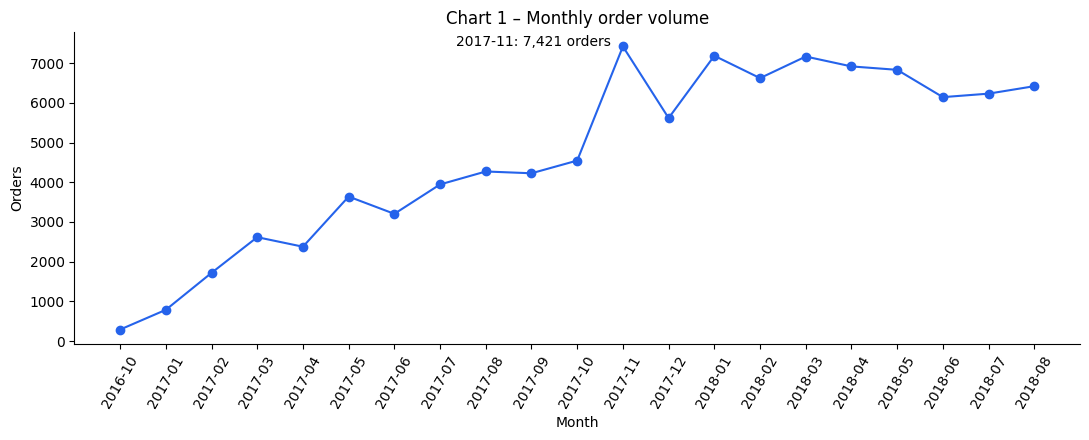

In [38]:
# Chart 1 – Monthly order volume
m = monthly[monthly["orders"] >= 100]           # months with fewer than 100 orders are incomplete edges
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(m["year_month"], m["orders"], marker="o", color="#2563eb")
peak = m.loc[m["orders"].idxmax()]
ax.annotate(f"{peak['year_month']}: {peak['orders']:,} orders", (peak["year_month"], peak["orders"]),
            textcoords="offset points", xytext=(-120, 0))
ax.set_title("Chart 1 – Monthly order volume"); ax.set_xlabel("Month"); ax.set_ylabel("Orders")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.savefig("charts/chart1_monthly_orders.png"); plt.show()

**Result:** monthly orders grew from 787 in January 2017 to between 6,100 and 7,200 per month during 2018. The highest month was **November 2017 with 7,421 orders** (Black Friday period).

**Meaning:** the marketplace grew quickly during 2017 and then stabilised at a higher level in 2018. November is a clear demand peak.

**Business relevance:** stock, seller capacity, logistics and customer service should be planned in advance for November, and marketing campaigns can target this peak.

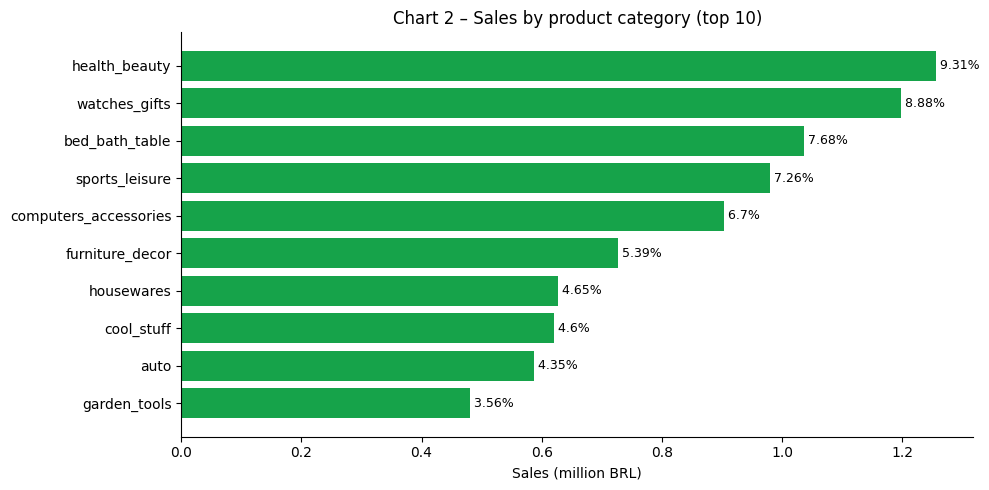

In [39]:
# Chart 2 – Sales by product category (top 10)
c = category.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(c["product_category"], c["sales"] / 1e6, color="#16a34a")
for i, (v, s) in enumerate(zip(c["sales"] / 1e6, c["sales_share_pct"])):
    ax.text(v, i, f" {s}%", va="center", fontsize=9)
ax.set_title("Chart 2 – Sales by product category (top 10)"); ax.set_xlabel("Sales (million BRL)")
plt.tight_layout(); plt.savefig("charts/chart2_sales_by_category.png"); plt.show()

**Result:** the top categories by sales are health_beauty (**9.31%**), watches_gifts (8.88%) and bed_bath_table (7.68%). The top 5 categories generate **39.8%** of product sales. bed_bath_table has the most orders (9,399), while watches_gifts has the highest average item price (R$ 200.70).

**Meaning:** sales are concentrated in a small number of categories, and categories reach high sales in different ways (many cheap items vs fewer expensive items).

**Business relevance:** the business can prioritise seller recruitment, promotions and stock availability in these categories, using volume strategies for bed_bath_table and value strategies for watches_gifts.

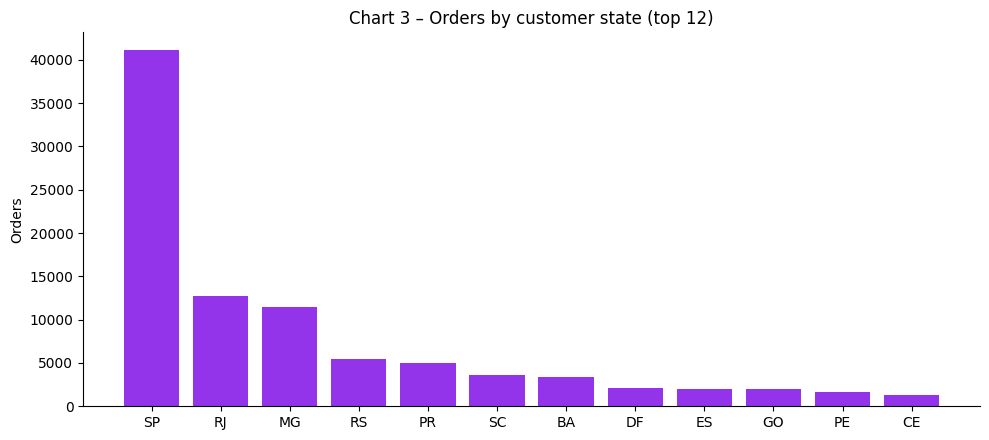

In [40]:
# Chart 3 – Orders by customer state (top 12)
s = state.head(12)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(s["customer_state"], s["orders"], color="#9333ea")
ax.set_title("Chart 3 – Orders by customer state (top 12)"); ax.set_ylabel("Orders")
plt.tight_layout(); plt.savefig("charts/chart3_orders_by_state.png"); plt.show()

**Result:** São Paulo (SP) accounts for **41.88%** of orders, followed by Rio de Janeiro (12.93%) and Minas Gerais (11.71%). Together these three states represent **66.5%** of all orders.

**Meaning:** customer demand is heavily concentrated in the South-East of Brazil.

**Business relevance:** warehouses and delivery partners near São Paulo serve most customers, while the other states are an opportunity for growth if delivery can be improved (see Chart 4).

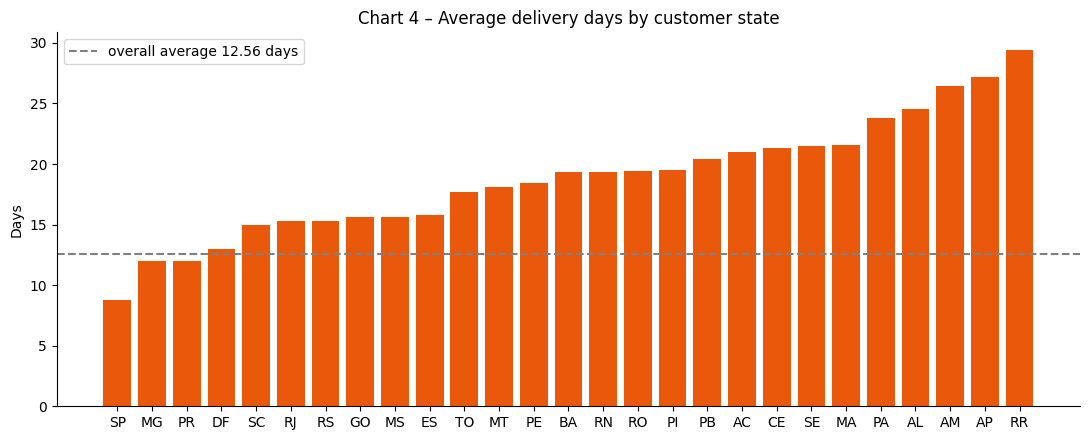

In [41]:
# Chart 4 – Average delivery days by customer state
d = state.dropna(subset=["avg_delivery_days"]).sort_values("avg_delivery_days")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(d["customer_state"], d["avg_delivery_days"], color="#ea580c")
ax.axhline(delivery["avg_delivery_days"][0], ls="--", color="grey",
           label=f"overall average {delivery['avg_delivery_days'][0]} days")
ax.set_title("Chart 4 – Average delivery days by customer state"); ax.set_ylabel("Days"); ax.legend()
plt.tight_layout(); plt.savefig("charts/chart4_delivery_days_by_state.png"); plt.show()

**Result:** the overall average delivery time is **12.56 days** (median 10.22). SP has the fastest delivery (**8.8 days**), while northern states wait much longer: RR 29.4, AP 27.2, AM 26.4, AL 24.5 and PA 23.8 days.

**Meaning:** customers far from the main seller locations wait 2–3 times longer than customers in São Paulo. Some of the slowest states have few orders, so their averages are less stable.

**Business relevance:** regional logistics partners or distribution points in the North and North-East could reduce delivery time and support growth in these states.

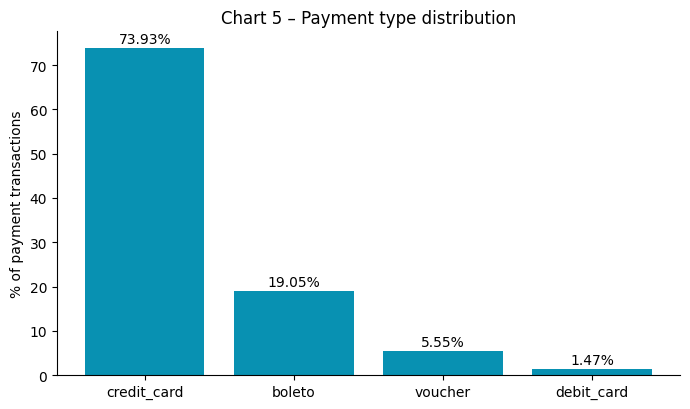

In [42]:
# Chart 5 – Payment type distribution
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(pay_type["payment_type"], pay_type["share_pct"], color="#0891b2")
for i, v in enumerate(pay_type["share_pct"]):
    ax.text(i, v + 1, f"{v}%", ha="center")
ax.set_title("Chart 5 – Payment type distribution"); ax.set_ylabel("% of payment transactions")
plt.tight_layout(); plt.savefig("charts/chart5_payment_types.png"); plt.show()

**Result:** credit card is used in **73.93%** of payment transactions, with an average of **3.51 instalments**. Boleto (bank slip) represents 19.05%, voucher 5.55% and debit card 1.47%.

**Meaning:** most customers pay by credit card and commonly split the payment into instalments. Boleto is still important for a significant share of customers.

**Business relevance:** keeping instalment options at checkout is important for conversion, and boleto should remain available for customers who do not use cards.

# 15. Results and Insights

| # | Calculation | Result | Interpretation | Actionable implication |
|---|---|---|---|---|
| 1 | average review score for late vs on-time deliveries | late **2.57** vs on-time **4.29**; scores of 1–2: **54.1%** vs 9.2%; 8.11% of orders late | late delivery is strongly associated with poor reviews (association, not proven cause) | reducing late deliveries is the most direct lever to improve customer satisfaction; monitor late orders and contact customers proactively |
| 2 | average delivery days by state | SP 8.8 days vs RR 29.4, AP 27.2, AM 26.4 | delivery performance depends strongly on region | add regional logistics partners in the North and North-East |
| 3 | orders by state and sales by category | SP + RJ + MG = 66.5% of orders; top 5 categories = 39.8% of sales | demand is concentrated geographically and by category | focus stock and sellers on key categories; treat other regions as growth markets |
| 4 | monthly orders | peak of 7,421 orders in November 2017 | strong seasonal demand around Black Friday | prepare capacity and campaigns before November |
| 5 | total orders vs unique customers | 98,199 orders from 94,983 customers (**≈1.03 orders per customer**) | almost all customers bought only once | retention actions (follow-up offers, loyalty programmes) could increase repeat purchases |

**Overall KPIs:** 98,199 orders · 94,983 customers · 3,053 sellers · 32,729 products · R$ 13.49M product sales + R$ 2.24M freight · average order value **R$ 160.24** (median R$ 105.28) · average review 4.1.

### Performance observations

In [43]:
perf = spark.createDataFrame([(k, round(v, 2)) for k, v in timings.items()], ["stage", "seconds"])
perf.show(truncate=False)
print("Input rows (8 raw files):", sum(r for _, r, _ in load_summary))
print("Final rows (integrated_data):", n_parquet, "| columns:", len(processed.columns))
print("Parquet partitions:", len([p for p in os.listdir(OUTPUT_PATH) if p.startswith("purchase_year")]),
      "| Spark cores:", spark.sparkContext.defaultParallelism,
      "| shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))

+-----------------------+-------+
|stage                  |seconds|
+-----------------------+-------+
|Data ingestion         |15.45  |
|Data quality assessment|20.12  |
|Data cleaning          |6.16   |
|Data integration       |37.34  |
|Transformation         |12.49  |
|Parquet write          |4.13   |
|Parquet read           |0.45   |
|Spark SQL analysis     |18.79  |
+-----------------------+-------+

Input rows (8 raw files): 550759
Final rows (integrated_data): 112650 | columns: 25
Parquet partitions: 3 | Spark cores: 1 | shuffle partitions: 8


Timings were measured in this runtime on a single machine (`local[*]`). Because Spark is lazy, each timing includes the work triggered by `count()` / `show()` in that section. Integration and quality assessment were the slowest stages because they contain many joins and full-table scans. `spark.sql.shuffle.partitions` was set to 8 instead of the default 200 because the data fits in memory on one machine.

# 16. Challenges and Solutions
| Challenge | Solution | Result |
|---|---|---|
| Review comments contain line breaks, breaking CSV rows | read reviews with `multiLine=True`, `escape='"'` | 99,224 reviews loaded correctly |
| All columns loaded as strings | explicit casts to timestamp, double and int | calculations and date differences work |
| Missing delivery dates and categories | retain delivery dates (exclude from delivery metrics); fill category with `unknown` | no orders or sales lost |
| Invalid payments (value 0, `not_defined`) | removed 9 payment rows | only valid financial values remain |
| 814 repeated review IDs and 547 orders with several reviews | kept the latest review per order with a window function | one review score per order, no duplicated items |
| One-to-many joins multiplying rows | aggregated payments and reviews to order level before joining; validated counts and totals | 112,650 rows, totals identical to source |
| New `customer_id` for every order | counted customers with `customer_unique_id` | realistic customer count |
| Item grain vs order grain | `COUNT(DISTINCT order_id)` and an order-level SQL view | order metrics not inflated |

# 17. Conclusion
A complete Apache Spark pipeline was built for the Olist dataset: 8 raw CSV files were ingested, quality-checked, cleaned, schema-aligned, joined at the correct grain, transformed, saved as partitioned Parquet and analysed with Spark SQL. Validation checks show the integrated dataset keeps exactly the same items, orders and sales as the source files.

**Main findings:** strong growth with a November 2017 peak, sales concentrated in a few categories and in São Paulo, credit card with instalments as the dominant payment, and late delivery strongly associated with low review scores.

**Limitations:** the pipeline ran on a single Colab machine, the data only covers 2016–2018, and the analysis shows associations, not causes.

**Future work:** run the same pipeline on a multi-node Spark cluster, schedule incremental loads for new orders, and add the geolocation file to analyse the effect of distance on delivery time.

In [44]:
spark.stop()